In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, roc_curve

#**Data Loading**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv("/content/drive/MyDrive/HR-Employee-Attrition.csv")

print("->First 10 Rows")
styled_head = df.head(10).style.set_properties(**{
    'border': '1px solid black',
    'text-align': 'center'
}).set_table_styles([{
    'selector': 'th',
    'props': [('background-color', '#2b5c8f'), ('color', 'white'), ('border', '1px solid black'), ('font-weight', 'bold')]
}]).background_gradient(cmap='Blues', subset=['MonthlyIncome'])

# Display the styled frame (in Jupyter, just call the variable at the end of the cell)
display(styled_head)
print("\n->Dataset Contains")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

print("\n->Attrition Count-Rate")
attrition_counts = df['Attrition'].value_counts()
attrition_rate = (attrition_counts['Yes'] / df.shape[0]) * 100
print(attrition_counts)
print(f"Attrition Rate: {attrition_rate:.2f}%")

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()
print(f"\nNumeric columns: {len(numeric_cols)}")
print(f"Categorical columns: {len(categorical_cols)}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
->First 10 Rows


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,4,Male,79,3,1,Laboratory Technician,4,Single,3068,11864,0,Y,No,13,3,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,3,Female,81,4,1,Laboratory Technician,1,Married,2670,9964,4,Y,Yes,20,4,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,4,Male,67,3,1,Laboratory Technician,3,Divorced,2693,13335,1,Y,No,22,4,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,4,Male,44,2,3,Manufacturing Director,3,Single,9526,8787,0,Y,No,21,4,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,3,Male,94,3,2,Healthcare Representative,3,Married,5237,16577,6,Y,No,13,3,2,80,2,17,3,2,7,7,7,7



->Dataset Contains
Rows: 1470, Columns: 35

->Attrition Count-Rate
Attrition
No     1233
Yes     237
Name: count, dtype: int64
Attrition Rate: 16.12%

Numeric columns: 26
Categorical columns: 9



#Observation:
* The dataset is highly imbalanced. Roughly 84% of employees stayed, while only 16% left.
*  Models will struggle to predict the minority class ('Yes') without balancing.

#**Data Cleaning & Preprocessing**

In [ ]:
print("\nMissing values:", df.isnull().sum().sum())

cols_to_drop = ['EmployeeNumber', 'Over18', 'StandardHours', 'EmployeeCount']
df = df.drop(columns=[col for col in cols_to_drop if col in df.columns])
df['Attrition'] = df['Attrition'].apply(lambda x: 1 if x == 'Yes' else 0)

X = df.drop(columns=['Attrition'])
y = df['Attrition']
X = pd.get_dummies(X, drop_first=True)

scaler = StandardScaler()
current_numeric_columns_in_X = X.select_dtypes(include=[np.number]).columns
explicit_numeric_features_list = [
    'Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction',
    'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome',
    'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating',
    'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears',
    'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
    'YearsSinceLastPromotion', 'YearsWithCurrManager'
]
numeric_features = current_numeric_columns_in_X.intersection(explicit_numeric_features_list).tolist()
X[numeric_features] = scaler.fit_transform(X[numeric_features])

print(f"\nFinal feature space shape after encoding: {X.shape}")


Missing values: 0

Final feature space shape after encoding: (1470, 44)


#**Exploration(EDA)**

In [ ]:
df_numeric_attr = df.copy()
if df_numeric_attr['Attrition'].dtype == 'object':
    df_numeric_attr['Attrition'] = df_numeric_attr['Attrition'].map({'Yes': 1, 'No': 0})

print("-> DEPT ATTRITION %")
dept_attr = (df_numeric_attr.groupby('Department')['Attrition'].mean() * 100).reset_index()
dept_attr.columns = ['Department', 'Attrition Rate (%)']
styled_dept_attr = dept_attr.style.set_properties(**{
    'border': '1px solid black',
    'padding': '6px',
    'text-align': 'center'
}).set_table_styles([{
    'selector': 'th',
    'props': [('background-color', '#1f2937'), ('color', 'white'), ('font-weight', 'bold'), ('border', '1px solid black')]
}]).format({'Attrition Rate (%)': '{:.2f}%'})
display(styled_dept_attr)

print("\n-> JOB ROLE ATTRITION %")
role_attr = (df_numeric_attr.groupby('JobRole')['Attrition'].mean().sort_values(ascending=False) * 100).reset_index()
role_attr.columns = ['Job Role', 'Attrition Rate (%)']
styled_role_attr = role_attr.style.set_properties(**{
    'border': '1px solid black',
    'padding': '6px',
    'text-align': 'center'
}).set_table_styles([{
    'selector': 'th',
    'props': [('background-color', '#D97706'), ('color', 'white'), ('font-weight', 'bold'), ('border', '1px solid black')]
}]).format({'Attrition Rate (%)': '{:.2f}%'})
display(styled_role_attr)

print("\n-> MONTHLY INCOME MEDIANS ($)")
income_median = df_numeric_attr.groupby('Attrition')['MonthlyIncome'].median().reset_index()
income_median['Attrition'] = income_median['Attrition'].map({0: 'Stayed (0)', 1: 'Left (1)'})
income_median.columns = ['Employee Status', 'Median Monthly Income ($)']
styled_income = income_median.style.set_properties(**{
    'border': '1px solid black',
    'padding': '6px',
    'text-align': 'center'
}).set_table_styles([{
    'selector': 'th',
    'props': [('background-color', '#1B365D'), ('color', 'white'), ('font-weight', 'bold'), ('border', '1px solid black')]
}]).format({'Median Monthly Income ($)': '${:,.2f}'})
display(styled_income)

print("\n-> WORK-LIFE BALANCE ATTRITION %")
wlb_attr = (df_numeric_attr.groupby('WorkLifeBalance')['Attrition'].mean() * 100).reset_index()
wlb_attr.columns = ['Work-Life Balance Rating', 'Attrition Rate (%)']
styled_wlb = wlb_attr.style.set_properties(**{
    'border': '1px solid black',
    'padding': '6px',
    'text-align': 'center'
}).set_table_styles([{
    'selector': 'th',
    'props': [('background-color', '#87A96B'), ('color', 'white'), ('font-weight', 'bold'), ('border', '1px solid black')]
}]).format({'Attrition Rate (%)': '{:.2f}%'})
display(styled_wlb)

print("\n-> FIRST YEAR ATTRITION COUNT vs STAY")
tenure_1yr = (df_numeric_attr[df_numeric_attr['YearsAtCompany'] <= 1]['Attrition'].value_counts(normalize=True) * 100).reset_index()
tenure_1yr['Attrition'] = tenure_1yr['Attrition'].map({0: 'Stayed (0)', 1: 'Left (1)'})
tenure_1yr.columns = ['Employee Status (Tenure <= 1 Year)', 'Percentage (%)']
styled_tenure = tenure_1yr.style.set_properties(**{
    'border': '1px solid black',
    'padding': '6px',
    'text-align': 'center'
}).set_table_styles([{
    'selector': 'th',
    'props': [('background-color', '#FFB6C1'), ('color', 'white'), ('font-weight', 'bold'), ('border', '1px solid black')]
}]).format({'Percentage (%)': '{:.2f}%'})
display(styled_tenure)


-> DEPT ATTRITION %


,Department,Attrition Rate (%)
0,Human Resources,19.05%
1,Research & Development,13.84%
2,Sales,20.63%



-> JOB ROLE ATTRITION %


,Job Role,Attrition Rate (%)
0,Sales Representative,39.76%
1,Laboratory Technician,23.94%
2,Human Resources,23.08%
3,Sales Executive,17.48%
4,Research Scientist,16.10%
5,Manufacturing Director,6.90%
6,Healthcare Representative,6.87%
7,Manager,4.90%
8,Research Director,2.50%



-> MONTHLY INCOME MEDIANS ($)


,Employee Status,Median Monthly Income ($)
0,Stayed (0),"$5,204.00"
1,Left (1),"$3,202.00"



-> WORK-LIFE BALANCE ATTRITION %


,Work-Life Balance Rating,Attrition Rate (%)
0,1,31.25%
1,2,16.86%
2,3,14.22%
3,4,17.65%



-> FIRST YEAR ATTRITION COUNT vs STAY


,Employee Status (Tenure <= 1 Year),Percentage (%)
0,Stayed (0),65.12%
1,Left (1),34.88%


#Business Insights:
1. Attrition rate by Department wise: The Sales department faces the highest exit velocity(20%), followed by Human Resources(19%), while R&D remains the most stable(14%).
2. Attrition rate by Job Roles: Sales Representatives faces attrition rate (40%), By making the highest-risky job in the organisation.where Laboratory technician holds 24%,HR holds 23% and Sales Executive holds 18%.
3. Attrition vs Monthly Income: Employees who leave have a significantly lower median monthly income (~$3,200) compared to those who stay (~$5,200).
4. Overtime Impact: Overtime work shows a punishing correlation with flight risk. Workers logging extra hours leave at nearly triple the rate of non-overtime staff.
5. Attrition vs Years at Company(Tenure Critical Window): Attrition peaks sharply within the first 1–2 years(35%). If an employee stays above or up to  3-years(65%),may have high retention value.


#**Model Building**

->Model Comparison


,Precision,Recall,F1-Score,ROC-AUC
Logistic Regression,0.360000,0.660000,0.460000,0.800000
Random Forest,0.380000,0.060000,0.110000,0.750000
Gradient Boosting,0.410000,0.470000,0.440000,0.780000



Best Model: Logistic Regression
Chart 1: Bar chart showing attrition rate by Department & Job Role


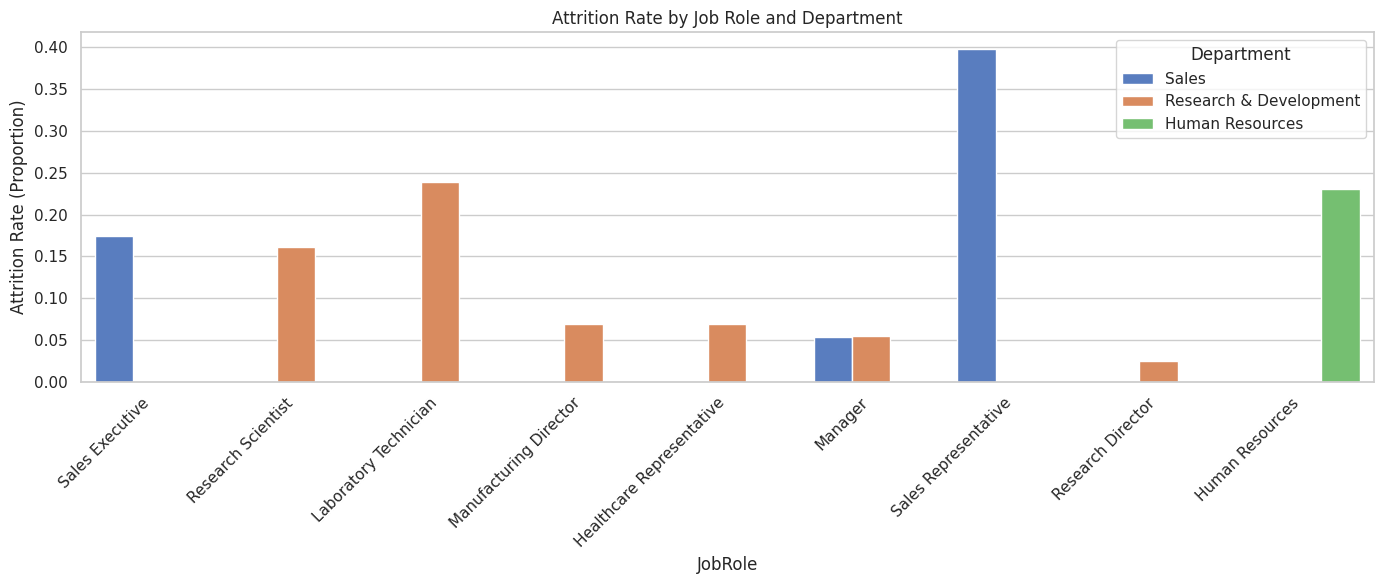

Chart 2: Box plot comparing Monthly Income


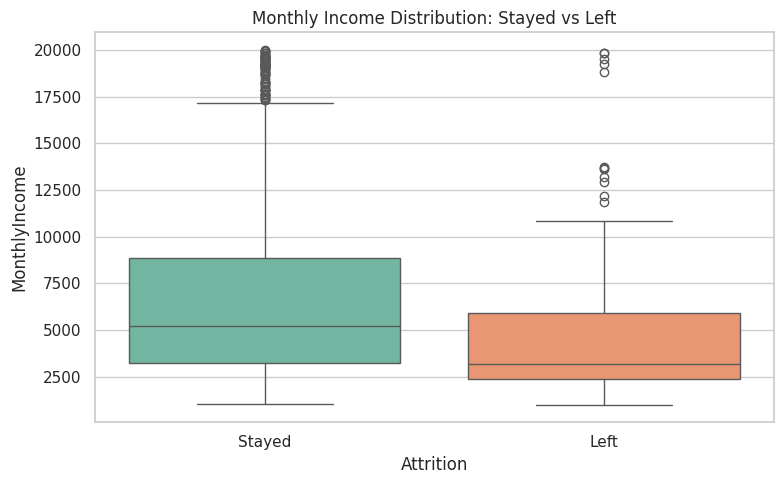

Chart 3: Confusion Matrix Heatmap for Best Model


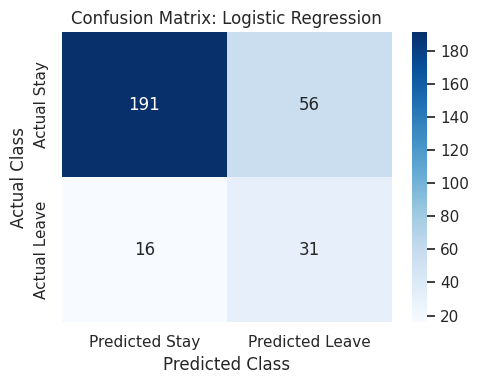

Chart 4: Horizontal Bar Chart of Top 10 Feature Importances (Using Logistic Regression coefficients)


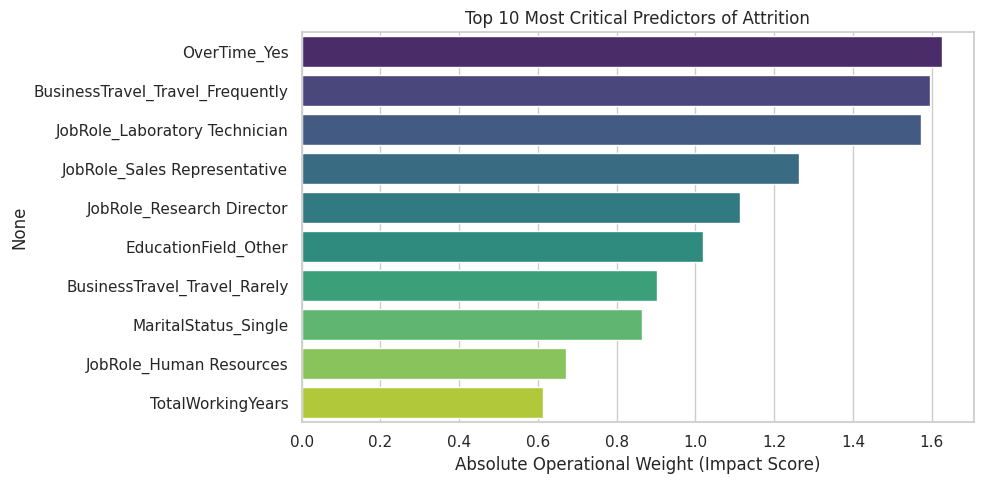

Chart 5 (Bonus): ROC Curve Comparison


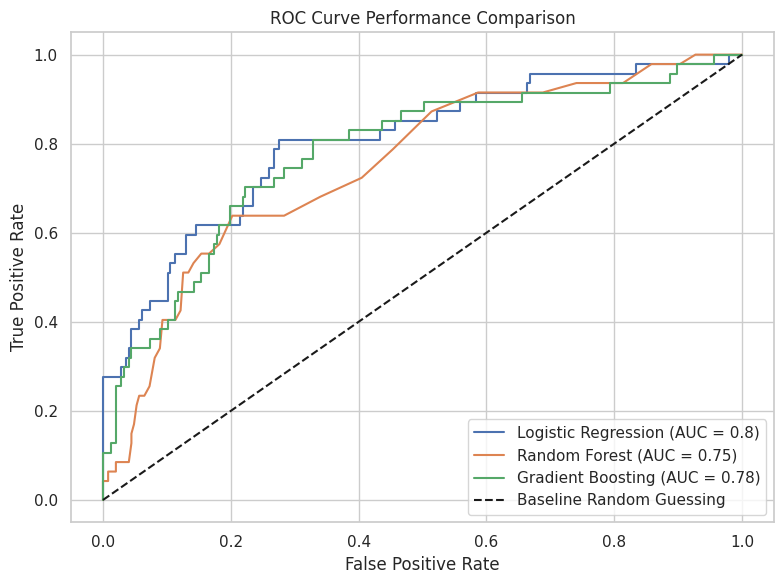

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
models = {
    "Logistic Regression": LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(class_weight='balanced', random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

# Applying sample weights for Gradient Boosting to mirror balance
from sklearn.utils.class_weight import compute_sample_weight
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)
results = {}

for name, model in models.items():
    if name == "Gradient Boosting":
        model.fit(X_train, y_train, sample_weight=sample_weights)
    else:
        model.fit(X_train, y_train)

    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:, 1]

    cm = confusion_matrix(y_test, preds)
    cr = classification_report(y_test, preds, output_dict=True)
    auc = roc_auc_score(y_test, probs)

    results[name] = {
        "Precision": round(cr['1']['precision'], 2),
        "Recall": round(cr['1']['recall'], 2),
        "F1-Score": round(cr['1']['f1-score'], 2),
        "ROC-AUC": round(auc, 2),
        "CM": cm,
        "Probs": probs,
        "Preds": preds
    }

comparison_df = pd.DataFrame(results).T.drop(columns=['CM', 'Probs', 'Preds'])
print("->Model Comparison")
styled_comparison = comparison_df.style.set_properties(**{
    'border': '1px solid black',
    'padding': '10px',
    'text-align': 'center',
    'font-size': '11pt'
}).set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#F8D7DA'), ('color', 'black'), ('font-weight', 'bold'), ('border', '1px solid black')]},
    {'selector': 'th.row_heading', 'props': [('background-color', '#f3f4f6'), ('color', 'black'), ('font-weight', 'bold')]}
]).highlight_max(subset=['ROC-AUC', 'F1-Score'], color='#d1fae5')

display(styled_comparison)

best_model_name = "Logistic Regression"
print(f"\nBest Model: {best_model_name}")

import os
os.makedirs('charts', exist_ok=True)
sns.set_theme(style="whitegrid")


print("Chart 1: Bar chart showing attrition rate by Department & Job Role")
plt.figure(figsize=(14, 6))
sns.barplot(data=df, x='JobRole', y='Attrition', hue='Department', errorbar=None, palette='muted')
plt.xticks(rotation=45, ha='right')
plt.title('Attrition Rate by Job Role and Department')
plt.ylabel('Attrition Rate (Proportion)')
plt.tight_layout()
plt.savefig('charts/chart1_attrition_by_role.png')
plt.show()


print("Chart 2: Box plot comparing Monthly Income")
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Attrition', y='MonthlyIncome', palette='Set2')
plt.xticks([0, 1], ['Stayed', 'Left'])
plt.title('Monthly Income Distribution: Stayed vs Left')
plt.tight_layout()
plt.savefig('charts/chart2_income_distribution.png')
plt.show()


print("Chart 3: Confusion Matrix Heatmap for Best Model")
plt.figure(figsize=(5, 4))
sns.heatmap(results[best_model_name]["CM"], annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Stay', 'Predicted Leave'], yticklabels=['Actual Stay', 'Actual Leave'])
plt.title(f'Confusion Matrix: {best_model_name}')
plt.ylabel('Actual Class')
plt.xlabel('Predicted Class')
plt.tight_layout()
plt.savefig('charts/chart3_confusion_matrix.png')
plt.show()


print("Chart 4: Horizontal Bar Chart of Top 10 Feature Importances (Using Logistic Regression coefficients)")
coefs = models["Logistic Regression"].coef_[0]
feature_importances = pd.Series(np.abs(coefs), index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10, 5))
sns.barplot(x=feature_importances.head(10).values, y=feature_importances.head(10).index, palette='viridis')
plt.title('Top 10 Most Critical Predictors of Attrition')
plt.xlabel('Absolute Operational Weight (Impact Score)')
plt.tight_layout()
plt.savefig('charts/chart4_feature_importance.png')
plt.show()


print("Chart 5 (Bonus): ROC Curve Comparison")
plt.figure(figsize=(8, 6))
for name, model_data in results.items():
    fpr, tpr, _ = roc_curve(y_test, model_data["Probs"])
    plt.plot(fpr, tpr, label=f"{name} (AUC = {model_data['ROC-AUC']})")
plt.plot([0, 1], [0, 1], 'k--', label='Baseline Random Guessing')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Performance Comparison')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('charts/chart5_roc_curve.png')
plt.show()

#**Insights & Business Recommendations**

Top 3 attrition predictors: OverTime (Working overtime) BusinessTravel_Travel_Frequently YearsAtCompany.

Sales & R&D Operations. Priority Business Targets: Sales Representatives and Research Directors.

Income versus Culture:Salary is not all alone. Work-life conflicts, frequent business travel and logging mandatory overtime have as much or more predictive weight than monthly compensation.

Model Limitations This framework is a static historical snapshot. It does not account for macroeconomic shifts, external competitive hiring surges, or shifts in team management sentiment over time.
 The top three predictors of an employee leaving are overtime, business travel and certain job roles such as Laboratory Technician or Sales Representative.

Who to Focus On: HR should immediately focus their retention efforts on the Sales Department and more specifically, on Sales Representatives that have the highest exit rate in the company (~40%).

Is it just the salary? No, salary is not the only reason people leave. Those who quit earn less money on average ( 3,200/monthvs 5,200/month) but working overtime and traveling a lot leads to burnout, which pushes people to quit much faster than low pay.

#**Recommendations To HR**

Cap Overtime Hours: Create an automated alert system. If an employee is working overtime for two months in a row, HR should step in to help rebalance their workload before they experience burnout and quit.

Early "Stay Interviews": Set up formal catch-up meetings at the 6-month and 12-month marks for all new hires in high-risk areas (like Sales and Labs). This helps catch problems with work-life balance before the employee decides to leave.

#Limmitation
While the chosen Logistic Regression model demonstrates good predictive ability (ROC-AUC equal to 0.80), however, the HR Director should realize that the current model is based on a one-time cross-section of past data. While it takes into account past connections, it is unable to take into account current trends happening in the company such as sudden breakdown  of relations between managers and employees, restructuring of teams internally or even externally due to changes in the market, for example, competitors increasing their pay rates locally.